Small LLM Output Dynamics Analyzer
==================================

A minimal transformer language model with 4 tokens in 2D space for visualizing attention dynamics.
This notebook implements a simplified transformer decoder to understand how attention mechanisms
create trajectories through embedding space.

Key Features:
- 4 token vocabulary (A, B, C, D)
- 2D embedding space for visualization
- Configurable layers and attention heads
- Causal (autoregressive) attention
- Temperature-controlled sampling
- Trajectory visualization and analysis

=== Basic Experiment ===
Initializing model with 1 layers, 1 heads, temperature=0.0, identity matrices

Generating trajectory starting from 'A'...

Step 1:
  Sequence: A
  Logits: A=0.250 B=0.314 C=0.000 D=0.171
  Next token: B

Step 2:
  Sequence: AB
  Logits: A=0.286 B=0.516 C=0.000 D=0.475
  Next token: B

Step 3:
  Sequence: ABB
  Logits: A=0.296 B=0.572 C=0.000 D=0.559
  Next token: B

Step 4:
  Sequence: ABBB
  Logits: A=0.301 B=0.599 C=0.000 D=0.599
  Next token: D

Step 5:
  Sequence: ABBBD
  Logits: A=0.269 B=0.632 C=0.000 D=0.708
  Next token: D

Generated sequence: ABBBDDDDDDDDDDDDDDD
Final entropy: -0.000
Attractor state: Strong attractor to D (p=1.000)

Detected cycles:
  - 'D' (length 1, starts at position 4)
  - 'DD' (length 2, starts at position 5)
  - 'DDD' (length 3, starts at position 4)
  - 'DDDD' (length 4, starts at position 7)
  - 'DDDDD' (length 5, starts at position 4)
  - 'DDDDDD' (length 6, starts at position 7)
  - 'DDDDDDD' (length 7, starts at position 5)


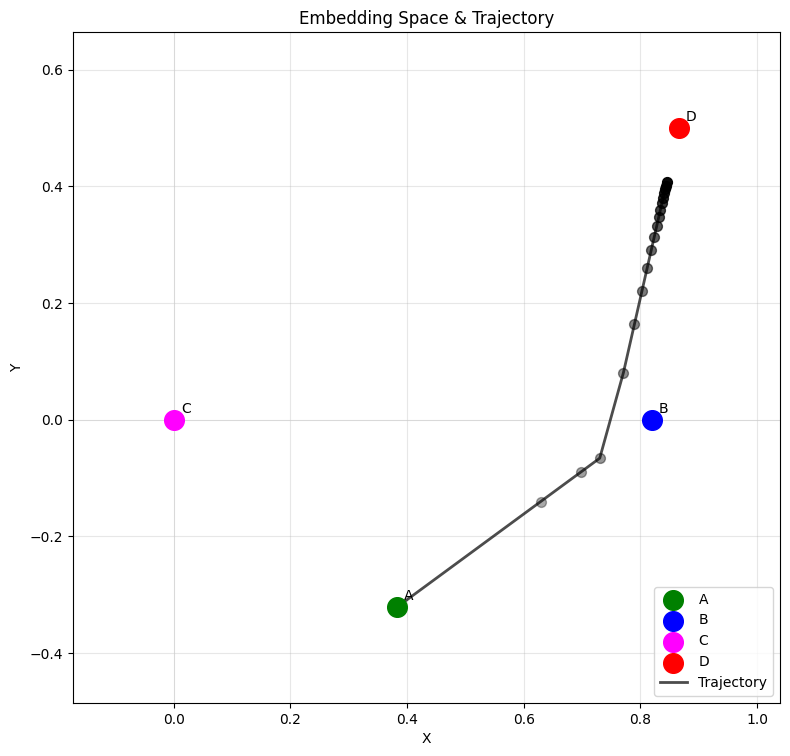

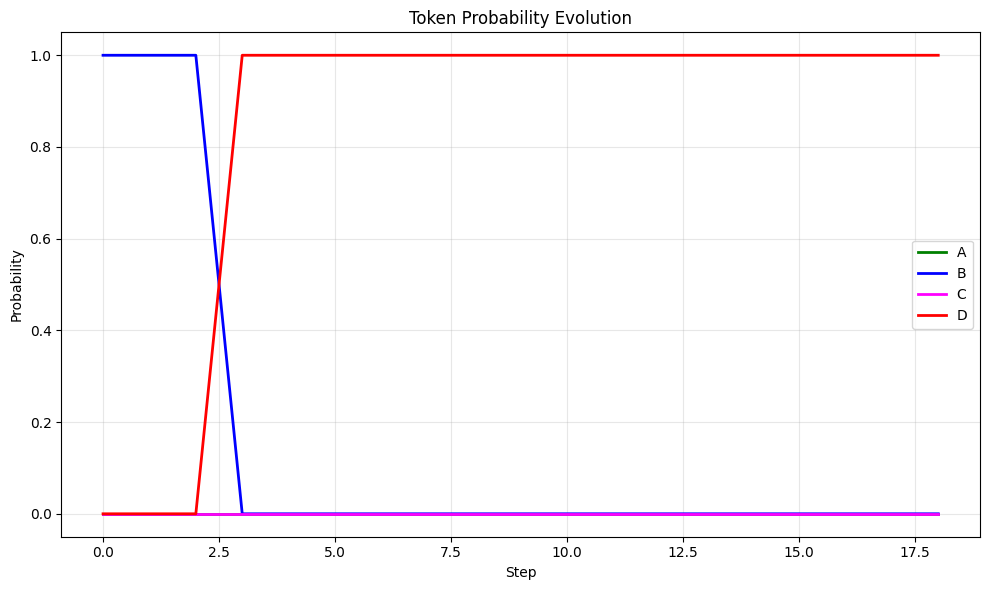


=== Identity Matrix Experiment ===
Initializing model with 1 layers, 1 heads, temperature=0.0, identity matrices

Generating trajectory starting from 'A'...

Step 1:
  Sequence: A
  Logits: A=0.250 B=0.314 C=0.000 D=0.171
  Next token: B

Step 2:
  Sequence: AB
  Logits: A=0.286 B=0.516 C=0.000 D=0.475
  Next token: B

Step 3:
  Sequence: ABB
  Logits: A=0.296 B=0.572 C=0.000 D=0.559
  Next token: B

Step 4:
  Sequence: ABBB
  Logits: A=0.301 B=0.599 C=0.000 D=0.599
  Next token: D

Step 5:
  Sequence: ABBBD
  Logits: A=0.269 B=0.632 C=0.000 D=0.708
  Next token: D

Generated sequence: ABBBDDDDDDDDDDDDDDD
Final entropy: -0.000
Attractor state: Strong attractor to D (p=1.000)

Detected cycles:
  - 'D' (length 1, starts at position 4)
  - 'DD' (length 2, starts at position 5)
  - 'DDD' (length 3, starts at position 4)
  - 'DDDD' (length 4, starts at position 7)
  - 'DDDDD' (length 5, starts at position 4)
  - 'DDDDDD' (length 6, starts at position 7)
  - 'DDDDDDD' (length 7, starts at p

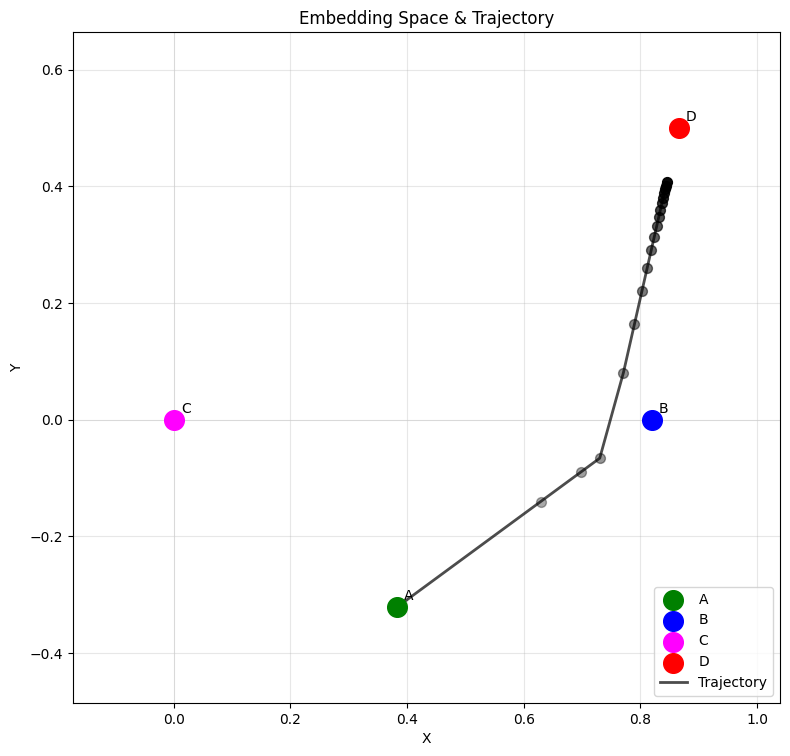

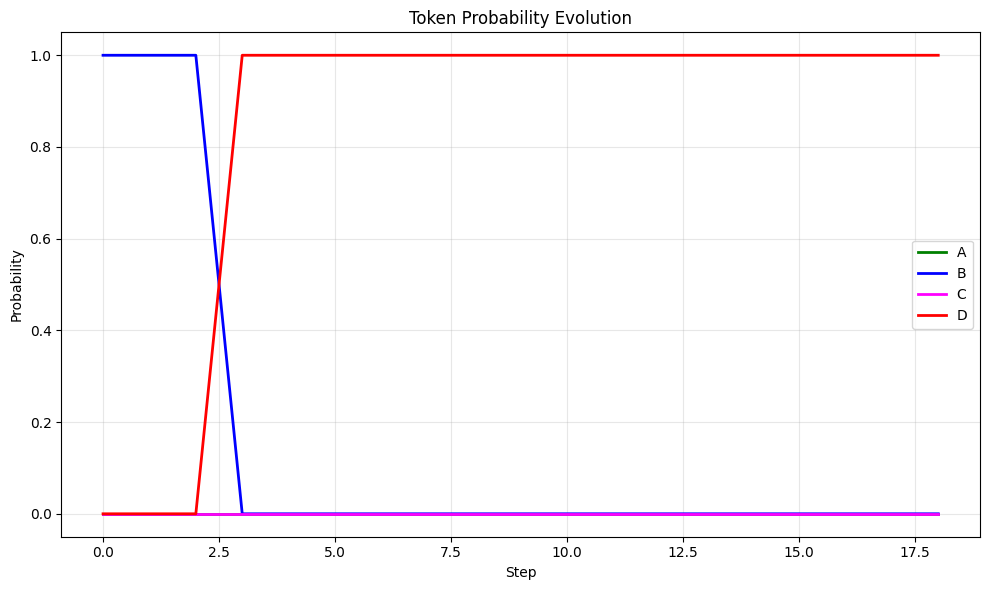


=== Weight Matrices ===
Matrix Initialization Type: Identity

Query (W_q):
[[1. 0.]
 [0. 1.]]

Key (W_k):
[[1. 0.]
 [0. 1.]]

Value (W_v):
[[1. 0.]
 [0. 1.]]

Output (W_o):
[[1. 0.]
 [0. 1.]]

Output Projection:
[[ 0.383  0.82   0.     0.866]
 [-0.321  0.     0.     0.5  ]]


=== Multiple Trajectories ===

Step 1:
  Sequence: A
  Logits: A=0.250 B=0.314 C=0.000 D=0.171
  Next token: B

Step 2:
  Sequence: AB
  Logits: A=0.286 B=0.516 C=0.000 D=0.475
  Next token: B

Step 3:
  Sequence: ABB
  Logits: A=0.296 B=0.572 C=0.000 D=0.559
  Next token: B

Step 4:
  Sequence: ABBB
  Logits: A=0.301 B=0.599 C=0.000 D=0.599
  Next token: D

Step 5:
  Sequence: ABBBD
  Logits: A=0.269 B=0.632 C=0.000 D=0.708
  Next token: D

Step 1:
  Sequence: B
  Logits: A=0.314 B=0.672 C=0.000 D=0.710
  Next token: D

Step 2:
  Sequence: BD
  Logits: A=0.235 B=0.693 C=0.000 D=0.870
  Next token: D

Step 3:
  Sequence: BDD
  Logits: A=0.213 B=0.699 C=0.000 D=0.916
  Next token: D

Step 4:
  Sequence: BDDD
  Log

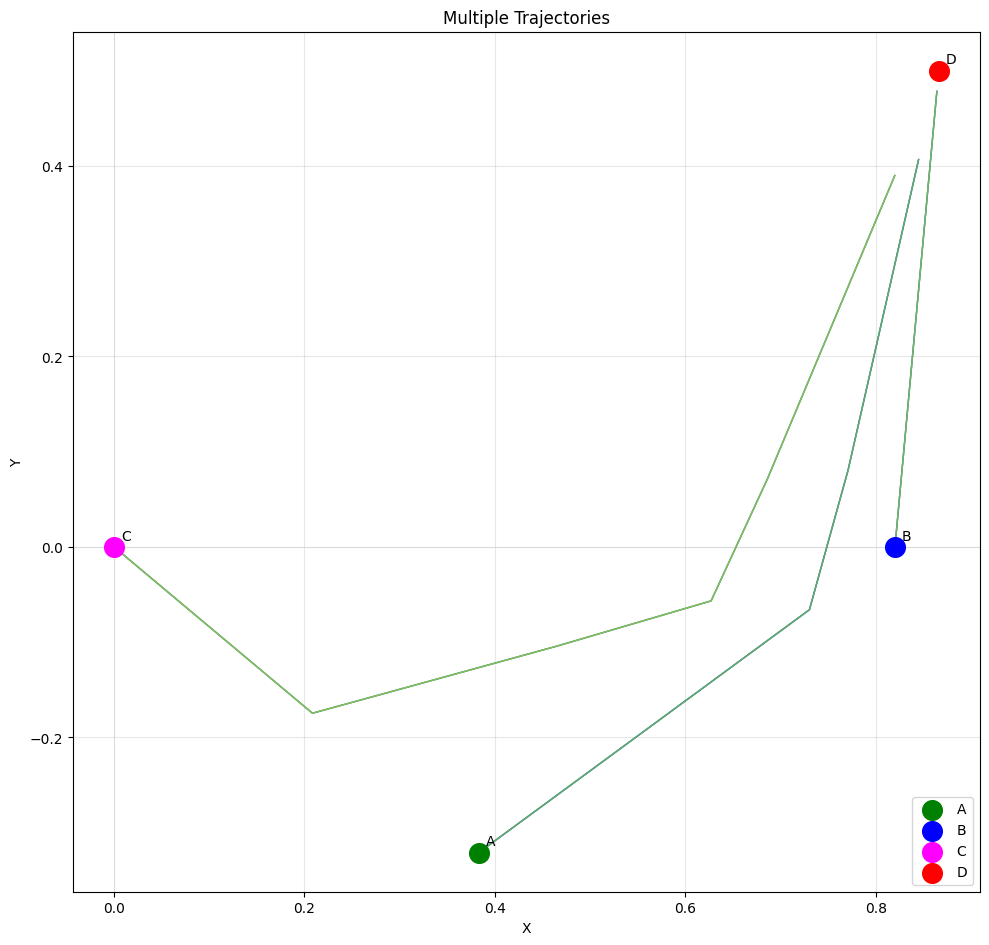


Final state distribution across trajectories:
  D: 20 trajectories (100.0%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Model configuration
VOCAB = ['A', 'B', 'C', 'D']
VOCAB_SIZE = 4
EMBEDDING_DIM = 2

# Default token embeddings (2D vectors)
# These can be modified to explore different dynamics
DEFAULT_EMBEDDINGS = {
    'A': np.array([0.383, -0.321]),
    'B': np.array([0.820, 0.0]),
    'C': np.array([0.000, 0.0]),
    'D': np.array([0.866, 0.5])
}

class MultiHeadAttention:
    """
    Multi-head attention mechanism.

    Note: This implementation shares parameters across heads, which is a simplification
    from real transformers where each head has its own parameters.
    """

    def __init__(self, dim, num_heads, use_identity_matrices=False):
        """
        Initialize multi-head attention.

        Args:
            dim: Embedding dimension
            num_heads: Number of attention heads
            use_identity_matrices: If True, use identity matrices for debugging
        """
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads  # Note: In this simple model, we use full dim
        self.use_identity_matrices = use_identity_matrices

        # Initialize weight matrices
        if use_identity_matrices:
            # Identity matrices for understanding pure attention dynamics
            self.W_q = np.eye(dim)
            self.W_k = np.eye(dim)
            self.W_v = np.eye(dim)
            self.W_o = np.eye(dim)
        else:
            # Random initialization with Xavier scaling
            scale = 1.0 / np.sqrt(dim)
            self.W_q = np.random.uniform(-scale, scale, (dim, dim))
            self.W_k = np.random.uniform(-scale, scale, (dim, dim))
            self.W_v = np.random.uniform(-scale, scale, (dim, dim))
            self.W_o = np.random.uniform(-scale, scale, (dim, dim))

    def forward(self, x, verbose=False):
        """
        Forward pass of multi-head attention.

        Args:
            x: Input sequence of shape (seq_len, dim)
            verbose: If True, print debug information

        Returns:
            Output of shape (seq_len, dim)
        """
        seq_len = len(x)

        # Compute queries, keys, and values
        # Q = XW_q, K = XW_k, V = XW_v
        Q = np.dot(x, self.W_q)
        K = np.dot(x, self.W_k)
        V = np.dot(x, self.W_v)

        if verbose and self.use_identity_matrices and seq_len <= 3:
            print("Attention Debug:")
            print(f"  Input embeddings: {x}")
            print(f"  Q: {Q}")
            print(f"  K: {K}")
            print(f"  V: {V}")

        # Compute attention scores: S = QK^T / sqrt(d)
        scores = np.dot(Q, K.T) / np.sqrt(self.dim)

        # Apply causal mask (can't attend to future tokens)
        # Set future positions to -inf so they become 0 after softmax
        for i in range(seq_len):
            scores[i, i+1:] = -np.inf

        if verbose and self.use_identity_matrices and seq_len <= 3:
            print(f"  Attention scores (before softmax): {scores}")

        # Apply softmax to get attention weights
        attn_weights = self._softmax(scores)

        if verbose and self.use_identity_matrices and seq_len <= 3:
            print(f"  Attention weights (after softmax): {attn_weights}")

        # Apply attention to values: Z = softmax(S)V
        attn_output = np.dot(attn_weights, V)

        if verbose and self.use_identity_matrices and seq_len <= 3:
            print(f"  Attention output (before W_o): {attn_output}")

        # Output projection
        output = np.dot(attn_output, self.W_o)

        if verbose and self.use_identity_matrices and seq_len <= 3:
            print(f"  Final attention output (after W_o): {output}")

        return output

    def _softmax(self, x):
        """Row-wise softmax with numerical stability."""
        # Handle -inf values properly
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        exp_x[np.isneginf(x)] = 0  # Set -inf positions to 0
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)


class FeedForward:
    """
    Feed-forward network with ReLU activation.
    Expands dimension from d to 4*d and back to d.
    """

    def __init__(self, dim, use_identity_matrices=False):
        """
        Initialize feed-forward network.

        Args:
            dim: Input/output dimension
            use_identity_matrices: If True, use identity-based initialization
        """
        self.dim = dim
        self.hidden_dim = dim * 4

        if use_identity_matrices:
            # Create identity-like matrices
            # W1: (dim, 4*dim) - expand with zeros
            self.W1 = np.zeros((dim, self.hidden_dim))
            self.W1[:dim, :dim] = np.eye(dim)

            # W2: (4*dim, dim) - truncate to identity
            self.W2 = np.zeros((self.hidden_dim, dim))
            self.W2[:dim, :dim] = np.eye(dim)
        else:
            # Random initialization with Xavier scaling
            self.W1 = np.random.uniform(-1, 1, (dim, self.hidden_dim)) / np.sqrt(dim)
            self.W2 = np.random.uniform(-1, 1, (self.hidden_dim, dim)) / np.sqrt(self.hidden_dim)

    def forward(self, x):
        """
        Forward pass: FFN(x) = max(0, xW1)W2

        Args:
            x: Input of shape (seq_len, dim)

        Returns:
            Output of shape (seq_len, dim)
        """
        # First linear layer with ReLU activation
        hidden = np.maximum(0, np.dot(x, self.W1))

        # Second linear layer
        output = np.dot(hidden, self.W2)

        return output


class LayerNorm:
    """
    Layer normalization with learnable parameters gamma and beta.
    """

    def __init__(self, dim, eps=1e-5):
        """
        Initialize layer normalization.

        Args:
            dim: Dimension to normalize
            eps: Small constant for numerical stability
        """
        self.dim = dim
        self.eps = eps
        self.gamma = np.ones(dim)  # Scale parameter
        self.beta = np.zeros(dim)  # Shift parameter

    def forward(self, x):
        """
        Apply layer normalization: LayerNorm(x) = gamma * (x - mu) / sqrt(var + eps) + beta

        Args:
            x: Input of shape (seq_len, dim)

        Returns:
            Normalized output of shape (seq_len, dim)
        """
        # Compute mean and variance along feature dimension
        mean = np.mean(x, axis=1, keepdims=True)
        var = np.var(x, axis=1, keepdims=True)

        # Normalize and apply learnable parameters
        x_norm = (x - mean) / np.sqrt(var + self.eps)
        output = self.gamma * x_norm + self.beta

        return output


class TransformerModel:
    """
    Simplified transformer decoder model.

    Architecture:
    - Multiple transformer layers
    - Each layer has: MultiHeadAttention -> LayerNorm -> FeedForward -> LayerNorm
    - Residual connections around each sub-layer
    - Final projection to vocabulary size
    """

    def __init__(self, num_layers, num_heads, temperature, embeddings, use_identity_matrices=False):
        """
        Initialize transformer model.

        Args:
            num_layers: Number of transformer layers
            num_heads: Number of attention heads per layer
            temperature: Sampling temperature (0 for deterministic)
            embeddings: Dictionary mapping tokens to embedding vectors
            use_identity_matrices: If True, use identity matrices
        """
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.temperature = temperature
        self.embeddings = embeddings
        self.use_identity_matrices = use_identity_matrices

        # Validate embedding dimension divisibility
        if EMBEDDING_DIM % num_heads != 0:
            print(f"Warning: Embedding dimension ({EMBEDDING_DIM}) is not evenly divisible "
                  f"by number of heads ({num_heads}). Using full dimension attention.")

        # Initialize layers
        self.layers = []
        for i in range(num_layers):
            layer = {
                'attention': MultiHeadAttention(EMBEDDING_DIM, num_heads, use_identity_matrices),
                'ffn': FeedForward(EMBEDDING_DIM, use_identity_matrices),
                'ln1': LayerNorm(EMBEDDING_DIM),
                'ln2': LayerNorm(EMBEDDING_DIM)
            }
            self.layers.append(layer)

        # Output projection matrix (embedding_dim x vocab_size)
        if use_identity_matrices:
            # Create a matrix that maps embeddings back to vocabulary
            # This is essentially the transpose of the embedding matrix
            self.W_out = np.array([embeddings[token] for token in VOCAB]).T
        else:
            self.W_out = np.random.uniform(-1, 1, (EMBEDDING_DIM, VOCAB_SIZE)) / np.sqrt(EMBEDDING_DIM)

    def forward(self, sequence, verbose=False):
        """
        Forward pass through the transformer.

        Args:
            sequence: List of tokens
            verbose: If True, print debug information

        Returns:
            Dictionary with:
                - representation: Final hidden state of last token
                - logits: Output scores for each vocabulary token
                - probs: Probability distribution over vocabulary
        """
        # Convert sequence to embeddings
        x = np.array([self.embeddings[token] for token in sequence])

        # Pass through transformer layers
        for i, layer in enumerate(self.layers):
            # Multi-head attention with residual connection
            attn_out = layer['attention'].forward(x, verbose=verbose)

            if self.use_identity_matrices and self.num_layers == 1:
                # Skip residual and layer norm for pure attention analysis
                x = attn_out
            else:
                # Add residual connection and normalize
                x = x + attn_out
                x = layer['ln1'].forward(x)

                # Feed-forward with residual connection
                ffn_out = layer['ffn'].forward(x)
                x = x + ffn_out
                x = layer['ln2'].forward(x)

        # Get representation of last token
        last_representation = x[-1]

        # Project to vocabulary size
        logits = np.dot(last_representation, self.W_out)

        if verbose and self.use_identity_matrices and self.temperature == 0:
            print(f"Last representation: {last_representation}")
            print(f"Output projection matrix:\n{self.W_out}")
            print(f"Logits: {logits}")

        # Apply temperature and compute probabilities
        if self.temperature == 0:
            # Deterministic: argmax
            probs = np.zeros(VOCAB_SIZE)
            max_indices = np.where(logits == np.max(logits))[0]

            if len(max_indices) > 1:
                tokens_tied = [VOCAB[i] for i in max_indices]
                print(f"Tie detected at temperature 0: tokens {tokens_tied} "
                      f"all have logit {logits[max_indices[0]]:.3f}")

            probs[max_indices[0]] = 1.0
        else:
            # Stochastic: softmax with temperature
            scaled_logits = logits / self.temperature
            exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
            probs = exp_logits / np.sum(exp_logits)

        return {
            'representation': last_representation,
            'logits': logits,
            'probs': probs
        }

    def sample(self, probs):
        """
        Sample next token from probability distribution.

        Args:
            probs: Probability distribution over vocabulary

        Returns:
            Sampled token
        """
        if self.temperature == 0:
            # Deterministic: return token with probability 1
            return VOCAB[np.argmax(probs)]
        else:
            # Stochastic: sample from distribution
            return np.random.choice(VOCAB, p=probs)


def generate_trajectory(model, initial_token, max_length):
    """
    Generate a sequence trajectory through embedding space.

    Args:
        model: Transformer model
        initial_token: Starting token
        max_length: Maximum sequence length

    Returns:
        List of trajectory points, each containing:
            - sequence: Tokens generated so far
            - representation: Hidden state in embedding space
            - probs: Probability distribution
            - logits: Raw output scores
    """
    sequence = [initial_token]
    trajectory = []

    for i in range(max_length - 1):
        # Forward pass
        result = model.forward(sequence)

        # Store trajectory point
        trajectory.append({
            'sequence': sequence.copy(),
            'representation': result['representation'].copy(),
            'probs': result['probs'].copy(),
            'logits': result['logits'].copy()
        })

        # Sample next token
        next_token = model.sample(result['probs'])
        sequence.append(next_token)

        # Debug output for identity matrices
        if model.use_identity_matrices and model.temperature == 0 and i < 5:
            print(f"\nStep {i + 1}:")
            print(f"  Sequence: {''.join(sequence[:-1])}")
            logit_str = ' '.join([f'{VOCAB[j]}={result["logits"][j]:.3f}' for j in range(VOCAB_SIZE)])
            print(f"  Logits: {logit_str}")
            print(f"  Next token: {next_token}")

    return trajectory


def visualize_trajectory(trajectory, embeddings, title="Embedding Space & Trajectory"):
    """
    Visualize trajectory through 2D embedding space.

    Args:
        trajectory: List of trajectory points from generate_trajectory
        embeddings: Token embedding dictionary
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw axes
    ax.axhline(y=0, color='lightgray', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='lightgray', linestyle='-', linewidth=0.5)

    # Plot token embeddings
    colors = {'A': 'green', 'B': 'blue', 'C': 'magenta', 'D': 'red'}
    for token, color in colors.items():
        pos = embeddings[token]
        ax.scatter(pos[0], pos[1], c=color, s=200, label=token, zorder=5)
        ax.annotate(token, (pos[0], pos[1]), xytext=(5, 5), textcoords='offset points')

    # Extract trajectory points
    trajectory_points = np.array([t['representation'] for t in trajectory])

    # Plot trajectory
    if len(trajectory_points) > 0:
        ax.plot(trajectory_points[:, 0], trajectory_points[:, 1],
                'k-', linewidth=2, alpha=0.7, label='Trajectory')

        # Plot points along trajectory with increasing opacity
        for i, point in enumerate(trajectory_points):
            alpha = 0.3 + 0.7 * i / len(trajectory_points)
            ax.scatter(point[0], point[1], c='black', s=50, alpha=alpha, zorder=4)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # Set reasonable axis limits
    all_points = list(embeddings.values()) + (trajectory_points.tolist() if len(trajectory_points) > 0 else [])
    if all_points:
        all_points = np.array(all_points)
        margin = 0.2
        x_range = all_points[:, 0].max() - all_points[:, 0].min()
        y_range = all_points[:, 1].max() - all_points[:, 1].min()
        ax.set_xlim(all_points[:, 0].min() - margin * x_range,
                    all_points[:, 0].max() + margin * x_range)
        ax.set_ylim(all_points[:, 1].min() - margin * y_range,
                    all_points[:, 1].max() + margin * y_range)

    plt.tight_layout()
    return fig, ax


def visualize_probabilities(trajectory, title="Token Probability Evolution"):
    """
    Visualize how token probabilities evolve over time.

    Args:
        trajectory: List of trajectory points from generate_trajectory
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Extract probabilities for each token over time
    probs_over_time = np.array([t['probs'] for t in trajectory])
    steps = np.arange(len(trajectory))

    # Plot probability evolution for each token
    colors = {'A': 'green', 'B': 'blue', 'C': 'magenta', 'D': 'red'}
    for i, (token, color) in enumerate(colors.items()):
        ax.plot(steps, probs_over_time[:, i], color=color, linewidth=2, label=token)

    ax.set_xlabel('Step')
    ax.set_ylabel('Probability')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    return fig, ax


def find_cycles(sequence):
    """
    Find repeating cycles in a sequence.

    Args:
        sequence: String of tokens

    Returns:
        List of detected cycles with pattern, length, and starting position
    """
    cycles = []

    # Check for cycles of different lengths
    for length in range(1, len(sequence) // 2 + 1):
        for start in range(len(sequence) - length):
            pattern = sequence[start:start + length]

            # Check if pattern repeats
            is_cycle = True
            for i in range(start + length, len(sequence), length):
                if sequence[i:i + length] != pattern:
                    is_cycle = False
                    break

            # Require at least 2 repetitions
            if is_cycle and (len(sequence) - start) // length >= 2:
                cycles.append({
                    'pattern': pattern,
                    'length': length,
                    'start': start
                })
                break

    return cycles


def analyze_trajectory(trajectory):
    """
    Analyze trajectory for patterns, cycles, and convergence.

    Args:
        trajectory: List of trajectory points from generate_trajectory

    Returns:
        Dictionary with analysis results
    """
    # Get full sequence
    full_sequence = ''.join(trajectory[-1]['sequence'])

    # Find cycles
    cycles = find_cycles(full_sequence)

    # Calculate final entropy
    final_probs = trajectory[-1]['probs']
    entropy = -np.sum(final_probs * np.log(final_probs + 1e-10)) / np.log(VOCAB_SIZE)

    # Determine attractor state
    max_prob = np.max(final_probs)
    max_idx = np.argmax(final_probs)

    if max_prob > 0.9:
        attractor = f"Strong attractor to {VOCAB[max_idx]} (p={max_prob:.3f})"
    elif max_prob > 0.6:
        attractor = f"Weak attractor to {VOCAB[max_idx]} (p={max_prob:.3f})"
    else:
        prob_str = ', '.join([f"{VOCAB[i]}:{final_probs[i]:.2f}" for i in range(VOCAB_SIZE)])
        attractor = f"Mixed state: {prob_str}"

    return {
        'sequence': full_sequence,
        'cycles': cycles,
        'entropy': entropy,
        'attractor': attractor,
        'final_probs': final_probs
    }


def display_weight_matrices(model):
    """
    Display model weight matrices for inspection.

    Args:
        model: Transformer model
    """
    print(f"Matrix Initialization Type: {'Identity' if model.use_identity_matrices else 'Random'}\n")

    # Display first layer's attention matrices
    layer = model.layers[0]

    matrices = {
        'Query (W_q)': layer['attention'].W_q,
        'Key (W_k)': layer['attention'].W_k,
        'Value (W_v)': layer['attention'].W_v,
        'Output (W_o)': layer['attention'].W_o,
        'Output Projection': model.W_out
    }

    for name, matrix in matrices.items():
        print(f"{name}:")
        print(matrix)
        print()


def run_experiment(num_layers=1, num_heads=1, temperature=0.0, initial_token='A',
                   max_length=20, use_identity=True, embeddings=None):
    """
    Run a complete experiment with visualization.

    Args:
        num_layers: Number of transformer layers
        num_heads: Number of attention heads
        temperature: Sampling temperature
        initial_token: Starting token
        max_length: Maximum sequence length
        use_identity: Whether to use identity matrices
        embeddings: Token embeddings (uses default if None)

    Returns:
        model, trajectory, analysis results
    """
    if embeddings is None:
        embeddings = DEFAULT_EMBEDDINGS.copy()

    # Create model
    print(f"Initializing model with {num_layers} layers, {num_heads} heads, "
          f"temperature={temperature}, {'identity' if use_identity else 'random'} matrices")

    model = TransformerModel(num_layers, num_heads, temperature, embeddings, use_identity)

    # Generate trajectory
    print(f"\nGenerating trajectory starting from '{initial_token}'...")
    trajectory = generate_trajectory(model, initial_token, max_length)

    # Analyze results
    analysis = analyze_trajectory(trajectory)

    print(f"\nGenerated sequence: {analysis['sequence']}")
    print(f"Final entropy: {analysis['entropy']:.3f}")
    print(f"Attractor state: {analysis['attractor']}")

    if analysis['cycles']:
        print("\nDetected cycles:")
        for cycle in analysis['cycles']:
            print(f"  - '{cycle['pattern']}' (length {cycle['length']}, starts at position {cycle['start']})")
    else:
        print("\nNo cycles detected")

    # Visualize
    visualize_trajectory(trajectory, embeddings)
    plt.show()

    visualize_probabilities(trajectory)
    plt.show()

    return model, trajectory, analysis


def generate_multiple_trajectories(model, max_length=20, num_trajectories=20):
    """
    Generate multiple trajectories from different starting points.

    Args:
        model: Transformer model
        max_length: Maximum sequence length
        num_trajectories: Number of trajectories to generate

    Returns:
        List of trajectories
    """
    trajectories = []

    for i in range(num_trajectories):
        # Cycle through different initial tokens
        initial_token = VOCAB[i % VOCAB_SIZE]
        trajectory = generate_trajectory(model, initial_token, max_length)
        trajectories.append(trajectory)

    return trajectories


def visualize_multiple_trajectories(trajectories, embeddings, title="Multiple Trajectories"):
    """
    Visualize multiple trajectories on the same plot.

    Args:
        trajectories: List of trajectories
        embeddings: Token embeddings
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    # Draw axes
    ax.axhline(y=0, color='lightgray', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='lightgray', linestyle='-', linewidth=0.5)

    # Plot token embeddings
    colors = {'A': 'green', 'B': 'blue', 'C': 'magenta', 'D': 'red'}
    for token, color in colors.items():
        pos = embeddings[token]
        ax.scatter(pos[0], pos[1], c=color, s=200, label=token, zorder=5)
        ax.annotate(token, (pos[0], pos[1]), xytext=(5, 5), textcoords='offset points')

    # Plot each trajectory with transparency
    for i, trajectory in enumerate(trajectories):
        trajectory_points = np.array([t['representation'] for t in trajectory])
        if len(trajectory_points) > 0:
            # Use different colors for different trajectories
            color = plt.cm.viridis(i / len(trajectories))
            ax.plot(trajectory_points[:, 0], trajectory_points[:, 1],
                    color=color, linewidth=1, alpha=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    return fig, ax


# Example usage
if __name__ == "__main__":
    # Basic experiment with default settings
    print("=== Basic Experiment ===")
    model, trajectory, analysis = run_experiment()

    # Experiment with identity matrices
    print("\n=== Identity Matrix Experiment ===")
    model_identity, trajectory_identity, analysis_identity = run_experiment(use_identity=True)

    # Display weight matrices
    print("\n=== Weight Matrices ===")
    display_weight_matrices(model_identity)

    # Multiple trajectories
    print("\n=== Multiple Trajectories ===")
    trajectories = generate_multiple_trajectories(model, max_length=20, num_trajectories=20)
    visualize_multiple_trajectories(trajectories, DEFAULT_EMBEDDINGS)
    plt.show()

    # Analyze convergence across trajectories
    final_states = {}
    for traj in trajectories:
        final_probs = traj[-1]['probs']
        dominant_token = VOCAB[np.argmax(final_probs)]
        final_states[dominant_token] = final_states.get(dominant_token, 0) + 1

    print("\nFinal state distribution across trajectories:")
    for token, count in final_states.items():
        print(f"  {token}: {count} trajectories ({count/len(trajectories)*100:.1f}%)")